# Exploratory Data Analysis

This notebook starts by loading the cleaned monthly gas and electricity usage datasets from `data/clean/` into pandas DataFrames.

Available DataFrames:
- `gas_monthly_usage`
- `electric_monthly_usage`


In [1]:
from pathlib import Path

import pandas as pd


def find_project_root() -> Path:
    """Walk upward until the repository root containing data/clean is found."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "clean").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing data/clean.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "clean"

gas_monthly_usage = pd.read_csv(
    DATA_DIR / "gas_monthly_usage.csv",
    parse_dates=["month"],
)

electric_monthly_usage = pd.read_csv(
    DATA_DIR / "electric_monthly_usage.csv",
    parse_dates=["month"],
)

print(f"Loaded gas data: {gas_monthly_usage.shape[0]:,} rows x {gas_monthly_usage.shape[1]} columns")
print(
    f"Loaded electricity data: {electric_monthly_usage.shape[0]:,} rows x {electric_monthly_usage.shape[1]} columns"
)


Loaded gas data: 8,412 rows x 6 columns
Loaded electricity data: 19,656 rows x 6 columns


## Quick Preview

Use the cells below to confirm the datasets loaded correctly before adding visualizations.


In [2]:
display(gas_monthly_usage.head())
display(electric_monthly_usage.head())

pd.DataFrame(
    [
        {
            "dataset": "gas_monthly_usage",
            "rows": len(gas_monthly_usage),
            "columns": gas_monthly_usage.shape[1],
            "date_min": gas_monthly_usage["month"].min(),
            "date_max": gas_monthly_usage["month"].max(),
        },
        {
            "dataset": "electric_monthly_usage",
            "rows": len(electric_monthly_usage),
            "columns": electric_monthly_usage.shape[1],
            "date_min": electric_monthly_usage["month"].min(),
            "date_max": electric_monthly_usage["month"].max(),
        },
    ]
)


,Property Name,Portfolio Manager ID,Property Type - Self-Selected,Gross Floor Area,month,normalized_monthly_usage
0,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-01-01,23839.31
1,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-02-01,18735.80
2,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-03-01,14082.81
3,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-04-01,11537.50
4,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-05-01,7784.48


,Property Name,Portfolio Manager ID,Property Type - Self-Selected,Gross Floor Area,month,normalized_monthly_usage
0,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-01-01,3294191.84
1,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-02-01,3188060.05
2,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-03-01,2971166.22
3,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-04-01,2861591.94
4,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-05-01,3142472.63


,dataset,rows,columns,date_min,date_max
0,gas_monthly_usage,8412,6,2024-01-01,2024-12-01
1,electric_monthly_usage,19656,6,2024-01-01,2024-12-01


## Seasonal Trend in Average Gas Usage

The plot below shows the average `normalized_monthly_usage` across all buildings for each calendar month. It uses a derived summary table so the original `gas_monthly_usage` DataFrame remains unchanged for later analyses.


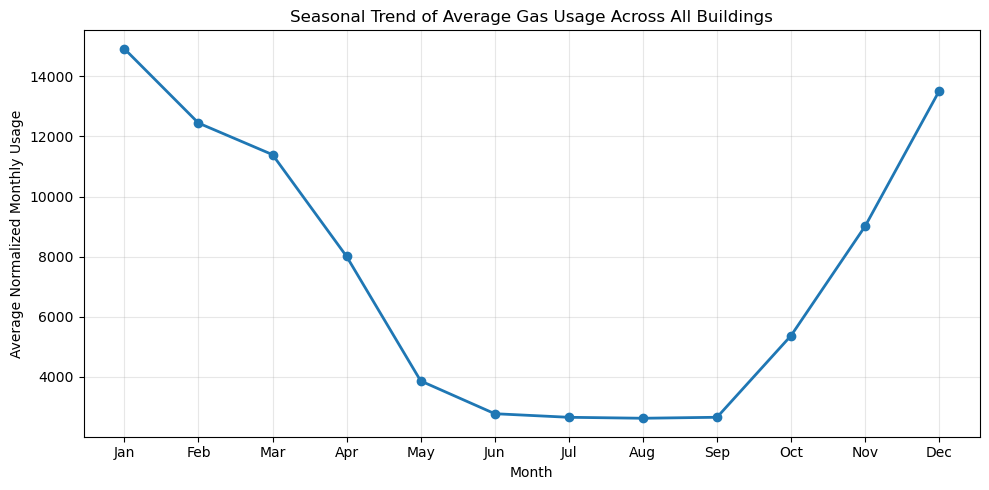

,month_name,normalized_monthly_usage
0,Jan,14913.383521
1,Feb,12443.828442
2,Mar,11392.615972
3,Apr,8006.733107
4,May,3866.861331
5,Jun,2777.387646
6,Jul,2658.095015
7,Aug,2626.290767
8,Sep,2658.892897
9,Oct,5375.861488


In [3]:
import matplotlib.pyplot as plt

gas_usage_for_trend = gas_monthly_usage[["month", "normalized_monthly_usage"]].copy()
gas_usage_for_trend["month"] = pd.to_datetime(gas_usage_for_trend["month"], errors="coerce")
gas_usage_for_trend = gas_usage_for_trend.dropna(subset=["month", "normalized_monthly_usage"])
gas_usage_for_trend["month_number"] = gas_usage_for_trend["month"].dt.month

gas_monthly_seasonal_trend = (
    gas_usage_for_trend.groupby("month_number", as_index=False)["normalized_monthly_usage"]
    .mean()
    .sort_values("month_number")
)

gas_monthly_seasonal_trend["month_name"] = pd.to_datetime(
    gas_monthly_seasonal_trend["month_number"],
    format="%m",
).dt.strftime("%b")

plt.figure(figsize=(10, 5))
plt.plot(
    gas_monthly_seasonal_trend["month_number"],
    gas_monthly_seasonal_trend["normalized_monthly_usage"],
    marker="o",
    linewidth=2,
)
plt.xticks(
    gas_monthly_seasonal_trend["month_number"],
    gas_monthly_seasonal_trend["month_name"],
)
plt.xlabel("Month")
plt.ylabel("Average Normalized Monthly Usage")
plt.title("Seasonal Trend of Average Gas Usage Across All Buildings")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(gas_monthly_seasonal_trend[["month_name", "normalized_monthly_usage"]])


## Seasonal Trend in Average Electricity Usage

The plot below shows the average `normalized_monthly_usage` across all buildings for each calendar month. It uses a derived summary table so the original `electric_monthly_usage` DataFrame remains unchanged for later analyses.


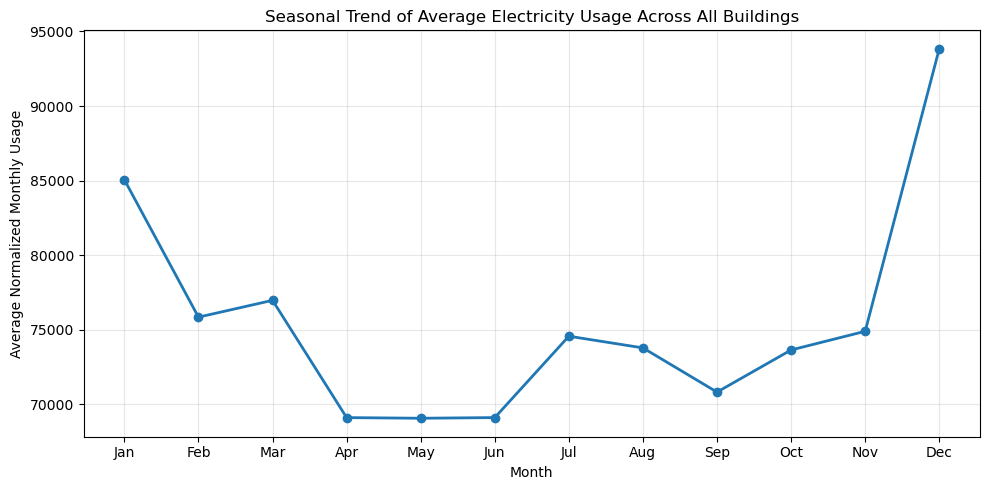

,month_name,normalized_monthly_usage
0,Jan,85055.228259
1,Feb,75846.112399
2,Mar,76972.153661
3,Apr,69109.219551
4,May,69066.354418
5,Jun,69111.122335
6,Jul,74567.749272
7,Aug,73783.830708
8,Sep,70819.829085
9,Oct,73644.295453


In [4]:
import matplotlib.pyplot as plt

electric_usage_for_trend = electric_monthly_usage[["month", "normalized_monthly_usage"]].copy()
electric_usage_for_trend["month"] = pd.to_datetime(electric_usage_for_trend["month"], errors="coerce")
electric_usage_for_trend = electric_usage_for_trend.dropna(subset=["month", "normalized_monthly_usage"])
electric_usage_for_trend["month_number"] = electric_usage_for_trend["month"].dt.month

electric_monthly_seasonal_trend = (
    electric_usage_for_trend.groupby("month_number", as_index=False)["normalized_monthly_usage"]
    .mean()
    .sort_values("month_number")
)

electric_monthly_seasonal_trend["month_name"] = pd.to_datetime(
    electric_monthly_seasonal_trend["month_number"],
    format="%m",
).dt.strftime("%b")

plt.figure(figsize=(10, 5))
plt.plot(
    electric_monthly_seasonal_trend["month_number"],
    electric_monthly_seasonal_trend["normalized_monthly_usage"],
    marker="o",
    linewidth=2,
)
plt.xticks(
    electric_monthly_seasonal_trend["month_number"],
    electric_monthly_seasonal_trend["month_name"],
)
plt.xlabel("Month")
plt.ylabel("Average Normalized Monthly Usage")
plt.title("Seasonal Trend of Average Electricity Usage Across All Buildings")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(electric_monthly_seasonal_trend[["month_name", "normalized_monthly_usage"]])


## Distribution of Gas Usage by Month

The boxplot below shows the distribution of `normalized_monthly_usage` for the gas dataset by calendar month. It uses a copied subset with derived month fields so the original `gas_monthly_usage` DataFrame remains unchanged for later visualizations.


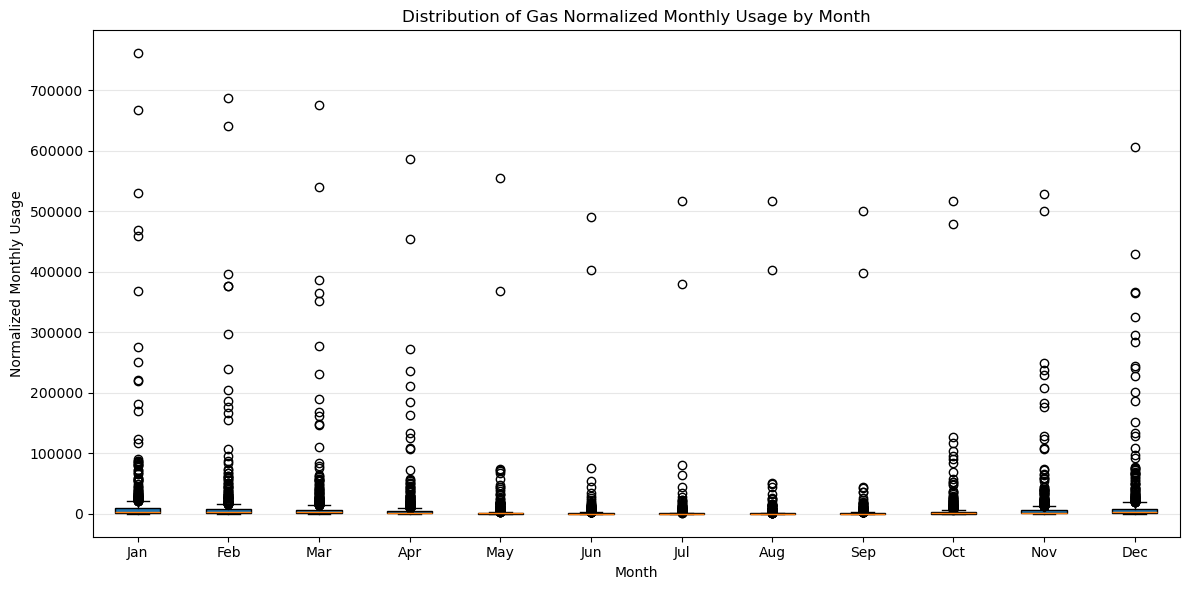

In [5]:
import matplotlib.pyplot as plt

gas_usage_for_boxplot = gas_monthly_usage[["month", "normalized_monthly_usage"]].copy()
gas_usage_for_boxplot["month"] = pd.to_datetime(gas_usage_for_boxplot["month"], errors="coerce")
gas_usage_for_boxplot = gas_usage_for_boxplot.dropna(subset=["month", "normalized_monthly_usage"])
gas_usage_for_boxplot["month_number"] = gas_usage_for_boxplot["month"].dt.month
gas_usage_for_boxplot["month_name"] = pd.to_datetime(
    gas_usage_for_boxplot["month_number"],
    format="%m",
).dt.strftime("%b")

gas_usage_for_boxplot = gas_usage_for_boxplot.sort_values("month_number")
month_labels = (
    gas_usage_for_boxplot[["month_number", "month_name"]]
    .drop_duplicates()
    .sort_values("month_number")
)
boxplot_data = [
    gas_usage_for_boxplot.loc[
        gas_usage_for_boxplot["month_number"] == month_number,
        "normalized_monthly_usage",
    ].values
    for month_number in month_labels["month_number"]
]

plt.figure(figsize=(12, 6))
plt.boxplot(boxplot_data, tick_labels=month_labels["month_name"], patch_artist=True)
plt.xlabel("Month")
plt.ylabel("Normalized Monthly Usage")
plt.title("Distribution of Gas Normalized Monthly Usage by Month")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Distribution of Electricity Usage by Month

The boxplot below shows the distribution of `normalized_monthly_usage` for the electricity dataset by calendar month. It uses a copied subset with derived month fields so the original `electric_monthly_usage` DataFrame remains unchanged for later visualizations.


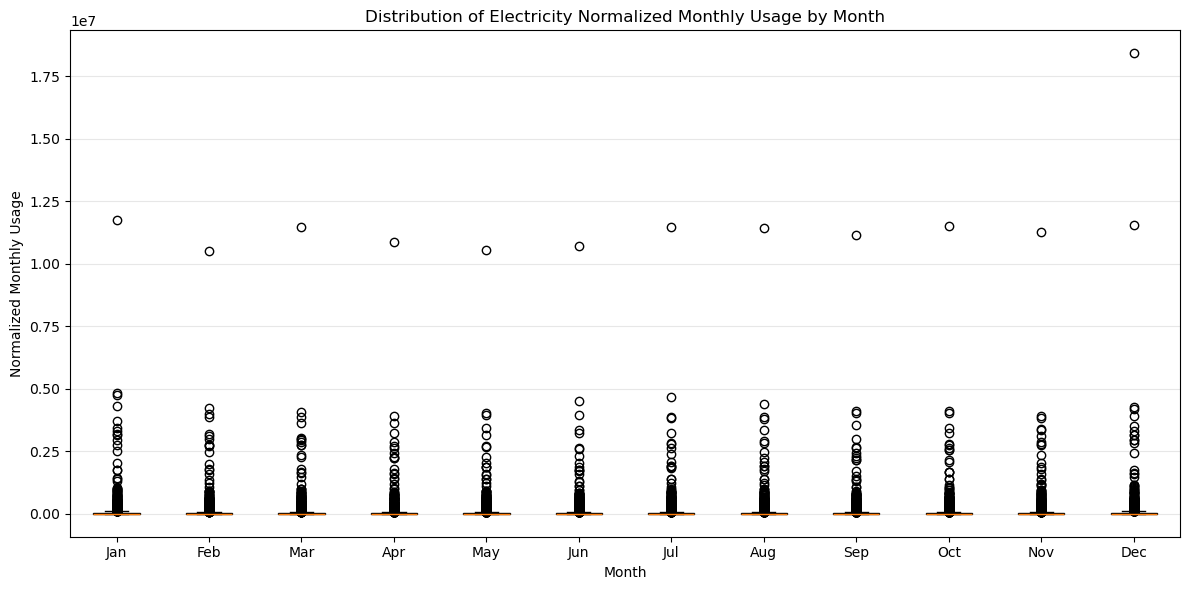

In [6]:
import matplotlib.pyplot as plt

electric_usage_for_boxplot = electric_monthly_usage[["month", "normalized_monthly_usage"]].copy()
electric_usage_for_boxplot["month"] = pd.to_datetime(electric_usage_for_boxplot["month"], errors="coerce")
electric_usage_for_boxplot = electric_usage_for_boxplot.dropna(subset=["month", "normalized_monthly_usage"])
electric_usage_for_boxplot["month_number"] = electric_usage_for_boxplot["month"].dt.month
electric_usage_for_boxplot["month_name"] = pd.to_datetime(
    electric_usage_for_boxplot["month_number"],
    format="%m",
).dt.strftime("%b")

electric_usage_for_boxplot = electric_usage_for_boxplot.sort_values("month_number")
month_labels = (
    electric_usage_for_boxplot[["month_number", "month_name"]]
    .drop_duplicates()
    .sort_values("month_number")
)
boxplot_data = [
    electric_usage_for_boxplot.loc[
        electric_usage_for_boxplot["month_number"] == month_number,
        "normalized_monthly_usage",
    ].values
    for month_number in month_labels["month_number"]
]

plt.figure(figsize=(12, 6))
plt.boxplot(boxplot_data, tick_labels=month_labels["month_name"], patch_artist=True)
plt.xlabel("Month")
plt.ylabel("Normalized Monthly Usage")
plt.title("Distribution of Electricity Normalized Monthly Usage by Month")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Relationship Between Gross Floor Area and Gas Usage

The scatter plot below shows `Gross Floor Area` on the x-axis and `normalized_monthly_usage` on the y-axis for the gas dataset. It uses a copied subset, separates placeholder rows where `Gross Floor Area == 1`, and plots only the filtered data so the original `gas_monthly_usage` DataFrame remains unchanged.


Filtered out 360 gas rows with placeholder Gross Floor Area = 1


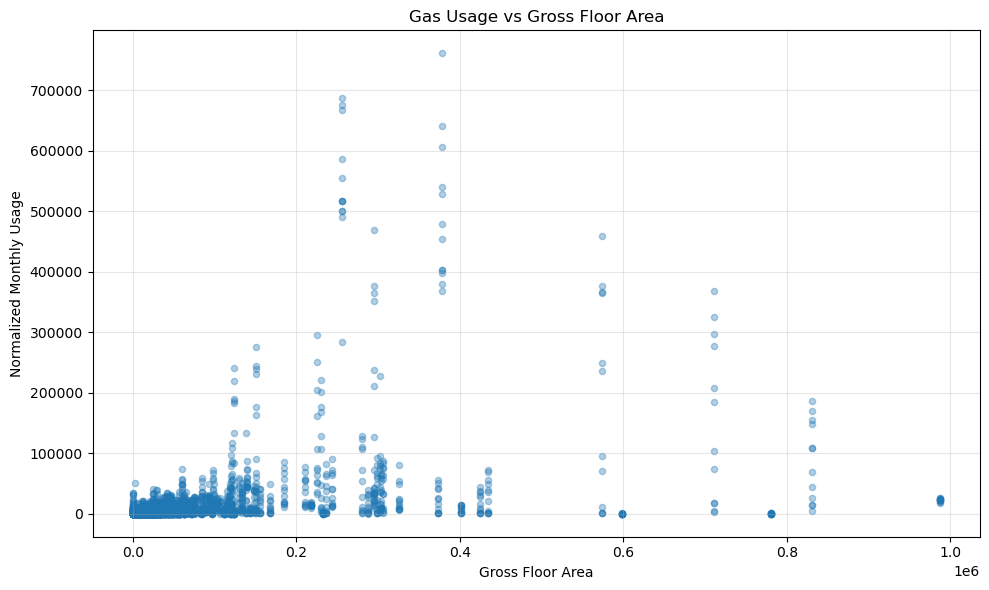

In [7]:
import matplotlib.pyplot as plt

gas_usage_for_scatter = gas_monthly_usage[["Gross Floor Area", "normalized_monthly_usage"]].copy()
gas_usage_for_scatter["Gross Floor Area"] = pd.to_numeric(
    gas_usage_for_scatter["Gross Floor Area"],
    errors="coerce",
)
gas_usage_for_scatter = gas_usage_for_scatter.dropna(subset=["Gross Floor Area", "normalized_monthly_usage"])
gas_placeholder_gfa_rows = gas_usage_for_scatter[
    gas_usage_for_scatter["Gross Floor Area"] == 1
].copy()
gas_usage_for_scatter_filtered = gas_usage_for_scatter[
    gas_usage_for_scatter["Gross Floor Area"] != 1
].copy()

print(f"Filtered out {len(gas_placeholder_gfa_rows):,} gas rows with placeholder Gross Floor Area = 1")

plt.figure(figsize=(10, 6))
plt.scatter(
    gas_usage_for_scatter_filtered["Gross Floor Area"],
    gas_usage_for_scatter_filtered["normalized_monthly_usage"],
    alpha=0.35,
    s=20,
)
plt.xlabel("Gross Floor Area")
plt.ylabel("Normalized Monthly Usage")
plt.title("Gas Usage vs Gross Floor Area")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Relationship Between Gross Floor Area and Electricity Usage

The scatter plot below shows `Gross Floor Area` on the x-axis and `normalized_monthly_usage` on the y-axis for the electricity dataset. It uses a copied subset, separates placeholder rows where `Gross Floor Area == 1`, and plots only the filtered data so the original `electric_monthly_usage` DataFrame remains unchanged.


Filtered out 5,964 electricity rows with placeholder Gross Floor Area = 1


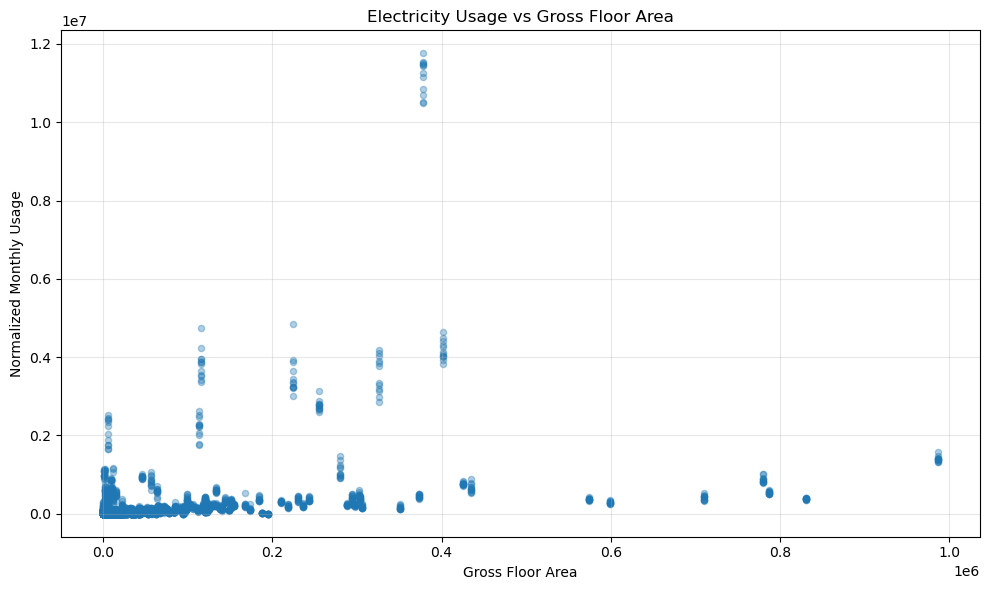

In [8]:
import matplotlib.pyplot as plt

electric_usage_for_scatter = electric_monthly_usage[["Gross Floor Area", "normalized_monthly_usage"]].copy()
electric_usage_for_scatter["Gross Floor Area"] = pd.to_numeric(
    electric_usage_for_scatter["Gross Floor Area"],
    errors="coerce",
)
electric_usage_for_scatter = electric_usage_for_scatter.dropna(subset=["Gross Floor Area", "normalized_monthly_usage"])
electric_placeholder_gfa_rows = electric_usage_for_scatter[
    electric_usage_for_scatter["Gross Floor Area"] == 1
].copy()
electric_usage_for_scatter_filtered = electric_usage_for_scatter[
    electric_usage_for_scatter["Gross Floor Area"] != 1
].copy()

print(f"Filtered out {len(electric_placeholder_gfa_rows):,} electricity rows with placeholder Gross Floor Area = 1")

plt.figure(figsize=(10, 6))
plt.scatter(
    electric_usage_for_scatter_filtered["Gross Floor Area"],
    electric_usage_for_scatter_filtered["normalized_monthly_usage"],
    alpha=0.35,
    s=20,
)
plt.xlabel("Gross Floor Area")
plt.ylabel("Normalized Monthly Usage")
plt.title("Electricity Usage vs Gross Floor Area")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Relationship Between Gross Floor Area and Average Gas Usage by Property

The scatter plot below shows `Gross Floor Area` on the x-axis and the average `normalized_monthly_usage` for each property on the y-axis for the gas dataset. It uses a copied subset, averages consumption after grouping by property, separates placeholder rows where `Gross Floor Area == 1`, and plots only the filtered properties so the original `gas_monthly_usage` DataFrame remains unchanged.


Filtered out 30 gas properties with placeholder Gross Floor Area = 1


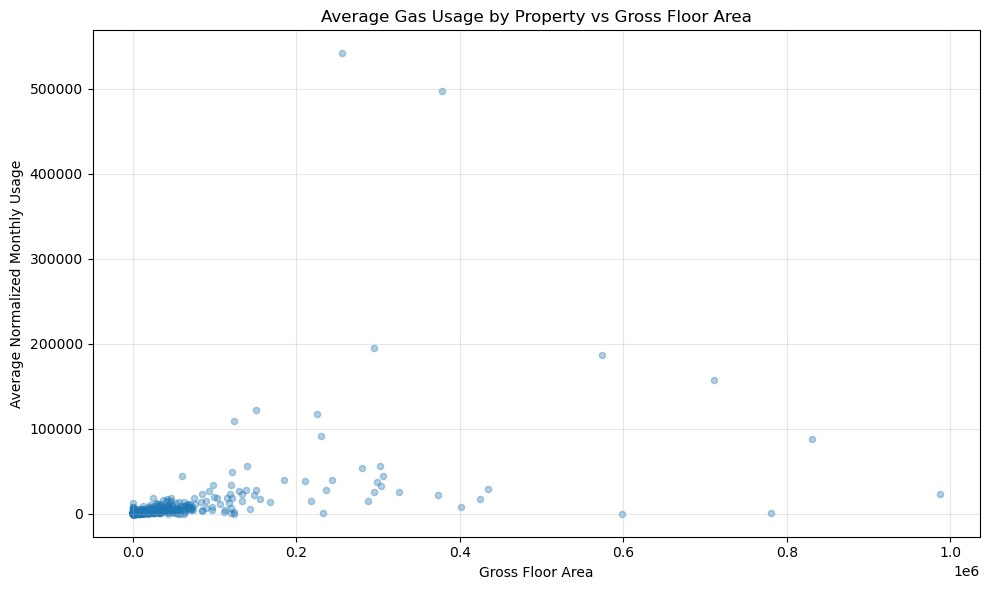

In [9]:
import matplotlib.pyplot as plt

gas_avg_usage_for_scatter = gas_monthly_usage[["Portfolio Manager ID", "Property Name", "Gross Floor Area", "normalized_monthly_usage"]].copy()
gas_avg_usage_for_scatter["Gross Floor Area"] = pd.to_numeric(
    gas_avg_usage_for_scatter["Gross Floor Area"],
    errors="coerce",
)
gas_avg_usage_for_scatter = gas_avg_usage_for_scatter.dropna(
    subset=["Portfolio Manager ID", "Gross Floor Area", "normalized_monthly_usage"]
)
gas_avg_usage_for_scatter = (
    gas_avg_usage_for_scatter.groupby(["Portfolio Manager ID", "Property Name"], as_index=False)
    .agg({"Gross Floor Area": "first", "normalized_monthly_usage": "mean"})
    .rename(columns={"normalized_monthly_usage": "average_normalized_monthly_usage"})
)
gas_avg_placeholder_gfa_rows = gas_avg_usage_for_scatter[
    gas_avg_usage_for_scatter["Gross Floor Area"] == 1
].copy()
gas_avg_usage_for_scatter_filtered = gas_avg_usage_for_scatter[
    gas_avg_usage_for_scatter["Gross Floor Area"] != 1
].copy()

print(f"Filtered out {len(gas_avg_placeholder_gfa_rows):,} gas properties with placeholder Gross Floor Area = 1")

plt.figure(figsize=(10, 6))
plt.scatter(
    gas_avg_usage_for_scatter_filtered["Gross Floor Area"],
    gas_avg_usage_for_scatter_filtered["average_normalized_monthly_usage"],
    alpha=0.35,
    s=20,
)
plt.xlabel("Gross Floor Area")
plt.ylabel("Average Normalized Monthly Usage")
plt.title("Average Gas Usage by Property vs Gross Floor Area")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Relationship Between Gross Floor Area and Average Electricity Usage by Property

The scatter plot below shows `Gross Floor Area` on the x-axis and the average `normalized_monthly_usage` for each property on the y-axis for the electricity dataset. It uses a copied subset, averages consumption after grouping by property, separates placeholder rows where `Gross Floor Area == 1`, and plots only the filtered properties so the original `electric_monthly_usage` DataFrame remains unchanged.


Filtered out 497 electricity properties with placeholder Gross Floor Area = 1


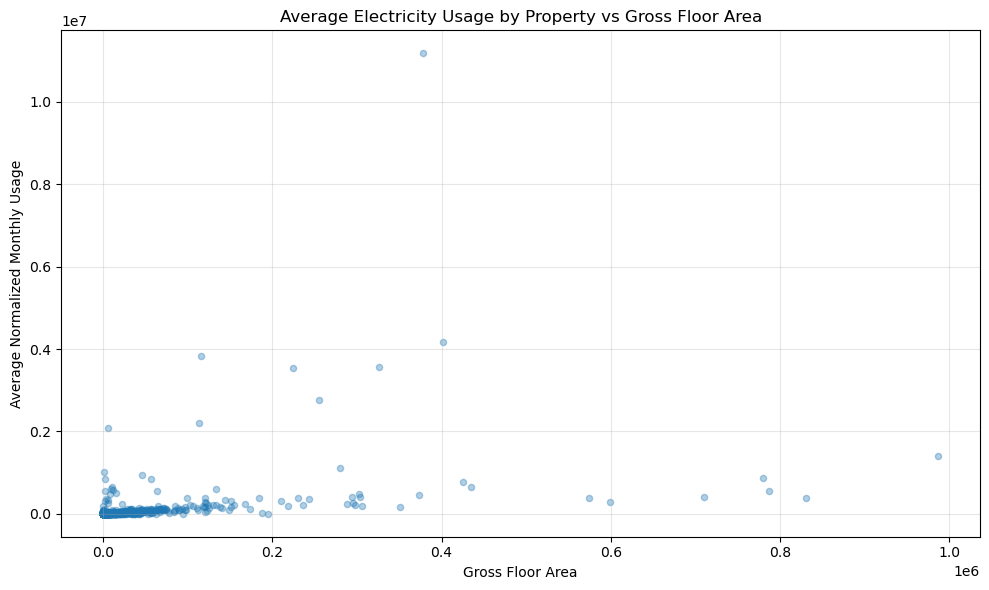

In [10]:
import matplotlib.pyplot as plt

electric_avg_usage_for_scatter = electric_monthly_usage[["Portfolio Manager ID", "Property Name", "Gross Floor Area", "normalized_monthly_usage"]].copy()
electric_avg_usage_for_scatter["Gross Floor Area"] = pd.to_numeric(
    electric_avg_usage_for_scatter["Gross Floor Area"],
    errors="coerce",
)
electric_avg_usage_for_scatter = electric_avg_usage_for_scatter.dropna(
    subset=["Portfolio Manager ID", "Gross Floor Area", "normalized_monthly_usage"]
)
electric_avg_usage_for_scatter = (
    electric_avg_usage_for_scatter.groupby(["Portfolio Manager ID", "Property Name"], as_index=False)
    .agg({"Gross Floor Area": "first", "normalized_monthly_usage": "mean"})
    .rename(columns={"normalized_monthly_usage": "average_normalized_monthly_usage"})
)
electric_avg_placeholder_gfa_rows = electric_avg_usage_for_scatter[
    electric_avg_usage_for_scatter["Gross Floor Area"] == 1
].copy()
electric_avg_usage_for_scatter_filtered = electric_avg_usage_for_scatter[
    electric_avg_usage_for_scatter["Gross Floor Area"] != 1
].copy()

print(f"Filtered out {len(electric_avg_placeholder_gfa_rows):,} electricity properties with placeholder Gross Floor Area = 1")

plt.figure(figsize=(10, 6))
plt.scatter(
    electric_avg_usage_for_scatter_filtered["Gross Floor Area"],
    electric_avg_usage_for_scatter_filtered["average_normalized_monthly_usage"],
    alpha=0.35,
    s=20,
)
plt.xlabel("Gross Floor Area")
plt.ylabel("Average Normalized Monthly Usage")
plt.title("Average Electricity Usage by Property vs Gross Floor Area")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
